# EDA del objetivo: univariado y bivariado

```{admonition} Alcance
:class: tip
Este capítulo usa solo el entrenamiento (enero de 2025 a abril de 2026). Las tasas son mensuales:
la probabilidad de renunciar en un mes dado. Los intervalos son de Wilson al 95 % y tratan las
filas como independientes, por lo que son algo optimistas (una persona aporta varios meses).
```

Para una tasa $\hat p = a / n$, el intervalo de Wilson es

$$
\frac{\hat p + \frac{z^2}{2n} \pm z \sqrt{\frac{\hat p (1 - \hat p)}{n} + \frac{z^2}{4n^2}}}
  {1 + \frac{z^2}{n}}, \qquad z = 1{,}96 .
$$

Se prefiere al intervalo de Wald ($\hat p \pm z \sqrt{\hat p (1 - \hat p) / n}$) porque con tasas
cercanas a cero este puede dar límites negativos y cubre menos de lo que dice.

In [1]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
from comun import (cargar, particion, estilo, tasa, tasa_ic, grafico_tasa, etiquetar, puntos,
                   OBJETIVO, NUM, BIN, CAT, PREDICTORAS, SEMILLA, NOMBRE, UNIDAD,
                   VERDE, ORO, GRIS, GRIS_CL, BORDE)

estilo()

tr, _ = particion(cargar())
BASE = 100 * tr[OBJETIVO].mean()
print(f'entrenamiento: {len(tr):,} filas | {int(tr[OBJETIVO].sum())} renuncias | '
      f'tasa mensual {BASE:.2f} %')

entrenamiento: 67,530 filas | 730 renuncias | tasa mensual 1.08 %


## El objetivo

La clase positiva es el 1 % de las filas. Una tasa mensual de 1 % equivale a que cerca de una de
cada nueve personas renuncie en un año. Este desbalance condiciona la métrica: un clasificador que
prediga que nadie renuncia acierta el 99 % de las veces sin identificar ninguna renuncia.

In [2]:
eventos = tr.evento.value_counts().to_frame('filas')
eventos['%'] = (100 * eventos.filas / len(tr)).round(2)
print(eventos.to_string())
print(f'\ntasa anual equivalente: {100 * (1 - (1 - BASE / 100) ** 12):.1f} %')
print('\notras salidas por tipo (y = 0 en su último mes):')
print(tr.tipo_retiro.value_counts().to_string())

                         filas      %
evento                               
ninguno                  66417  98.35
renuncia                   730   1.08
otra_salida                353   0.52
renuncia_administrativa     30   0.04

tasa anual equivalente: 12.2 %

otras salidas por tipo (y = 0 en su último mes):
tipo_retiro
Despido Injustificado              123
Despido Justificado                110
Vencimiento por termino Pactado    106
Fallecimiento                        9
Mutuo acuerdo                        4
Paso a Pensionado                    1


## Variables numéricas

### Distribución

Hay dos variables numéricas, edad y antigüedad. Ambas tienen cola larga a la derecha, y la
antigüedad concentra mucha masa en los primeros meses: la mitad de las personas lleva menos de tres
años.

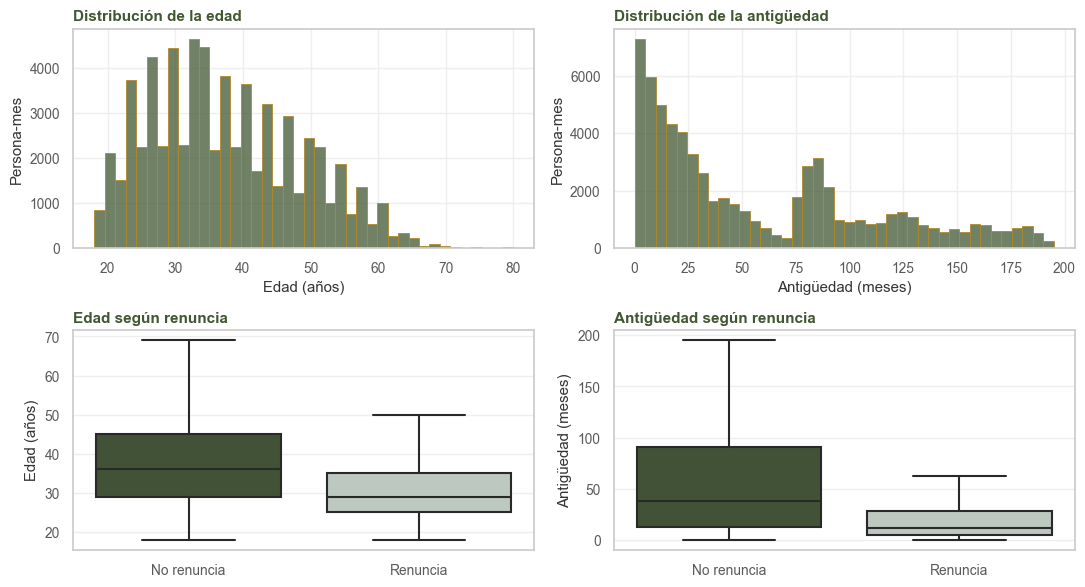

,count,mean,std,min,10%,25%,50%,75%,90%,max
edad,67530.0,37.4,11.1,18.0,24.0,28.0,36.0,45.0,53.0,80.0
antig_meses,67530.0,58.6,53.4,0.0,4.0,13.0,38.0,91.0,143.0,195.0


In [3]:
fig, ax = plt.subplots(2, 2, figsize=(11, 6))
for i, v in enumerate(NUM):
    sns.histplot(tr[v], bins=40, ax=ax[0, i], color=VERDE, **BORDE)
    ax[0, i].set(title=f'Distribución de la {NOMBRE[v]}', xlabel=UNIDAD[v], ylabel='Persona-mes')
    sns.boxplot(data=tr, x=OBJETIVO, y=v, ax=ax[1, i], showfliers=False,
                palette=[VERDE, GRIS_CL])
    ax[1, i].set(title=f'{NOMBRE[v].capitalize()} según renuncia', xlabel='', ylabel=UNIDAD[v])
    ax[1, i].set_xticklabels(['No renuncia', 'Renuncia'])
plt.tight_layout()
plt.show()

tr[NUM].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T.round(1)

In [4]:
filas = []
for v in NUM:
    x = tr[v].dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    k2, p_norm = stats.normaltest(x)
    filas.append({
        'variable': v,
        'asimetría': x.skew(),
        'curtosis (exceso)': x.kurt(),
        "D'Agostino K²": k2,
        'p normalidad': f'{p_norm:.1e}',
        'fuera de 1,5×IQR': int(((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum()),
    })
pd.DataFrame(filas).set_index('variable').round(2)

variable,asimetría,curtosis (exceso),D'Agostino K²,p normalidad,"fuera de 1,5×IQR"
edad,0.46,-0.53,3677.88,0.0e+00,73
antig_meses,0.79,-0.52,7010.08,0.0e+00,0


Las dos son asimétricas a la derecha; la antigüedad lo es más y tiene curtosis negativa (una
distribución ancha, con mucha masa al inicio y una meseta larga). La regresión logística no supone
normalidad de las predictoras, pero la asimetría de la antigüedad justifica incluirla también en
logaritmo (capítulo 7). Los 73 valores de edad por encima de las vallas son reales y se conservan
(en el panel completo son 102; sección 1.5).

```{admonition} Observación
:class: note
La prueba de normalidad rechaza con fuerza, como es de esperar con 67.530 filas: con una muestra
tan grande cualquier desviación mínima resulta significativa. Por eso se examina la forma de la
distribución y no solo el valor p.
```

### Relación entre edad y antigüedad

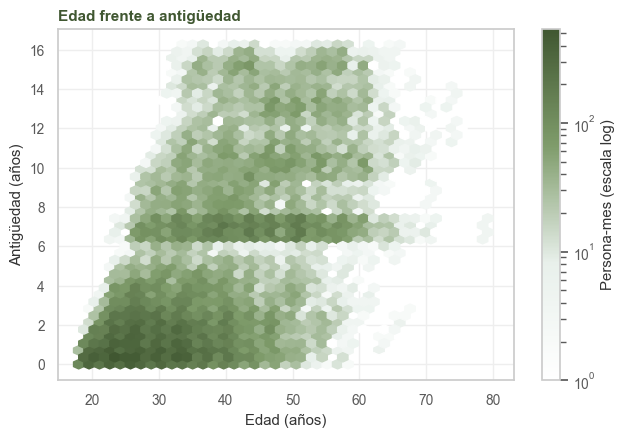

Pearson 0.60 | Spearman 0.60


In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
hb = ax.hexbin(tr.edad, tr.antig_meses / 12, gridsize=40, cmap='verde', mincnt=1, bins='log')
ax.set(title='Edad frente a antigüedad', xlabel='Edad (años)', ylabel='Antigüedad (años)')
fig.colorbar(hb, ax=ax, label='Persona-mes (escala log)')
plt.tight_layout()
plt.show()

r_pearson = stats.pearsonr(tr.edad.fillna(tr.edad.median()), tr.antig_meses)[0]
r_spearman = stats.spearmanr(tr.edad, tr.antig_meses, nan_policy='omit')[0]
print(f'Pearson {r_pearson:.2f} | Spearman {r_spearman:.2f}')

Como la antigüedad está acotada por la edad, la nube forma un triángulo bajo la diagonal. La
correlación es de 0,6 y no lineal. Las dos variables comparten información sin ser redundantes: a
una misma edad hay antigüedades de 0 a 15 años.

### Comparación según renuncia: Mann-Whitney

Como las distribuciones son asimétricas, comparamos con la prueba de Mann-Whitney en lugar de la
*t*. El tamaño del efecto es la correlación biserial de rangos, r = 1 − 2U/(n₁n₀), que va de −1 a 1;
en valor absoluto, 0,1 es un efecto pequeño, 0,3 mediano y 0,5 grande.

In [6]:
filas = []
for v in NUM:
    a = tr.loc[tr[OBJETIVO] == 1, v].dropna()
    b = tr.loc[tr[OBJETIVO] == 0, v].dropna()
    u, pv = stats.mannwhitneyu(a, b, alternative='two-sided')
    filas.append({
        'variable': v,
        'mediana renuncia': a.median(),
        'mediana no renuncia': b.median(),
        'U': u,
        'p': f'{pv:.1e}',
        'r biserial de rangos': 1 - 2 * u / (len(a) * len(b)),
    })
pd.DataFrame(filas).set_index('variable').round(3)

variable,mediana renuncia,mediana no renuncia,U,p,r biserial de rangos
edad,29.0,36.0,15832616.5,6.4e-60,0.351
antig_meses,12.0,38.0,14121615.5,2.0e-85,0.421


### Diferencias por grupo: Kruskal-Wallis

Diferencias de edad y antigüedad entre líneas de negocio, tipos de contrato y tipos de unidad. El
tamaño del efecto es ε² = H / (n − 1), la fracción de la variabilidad de los rangos que explican
los grupos.

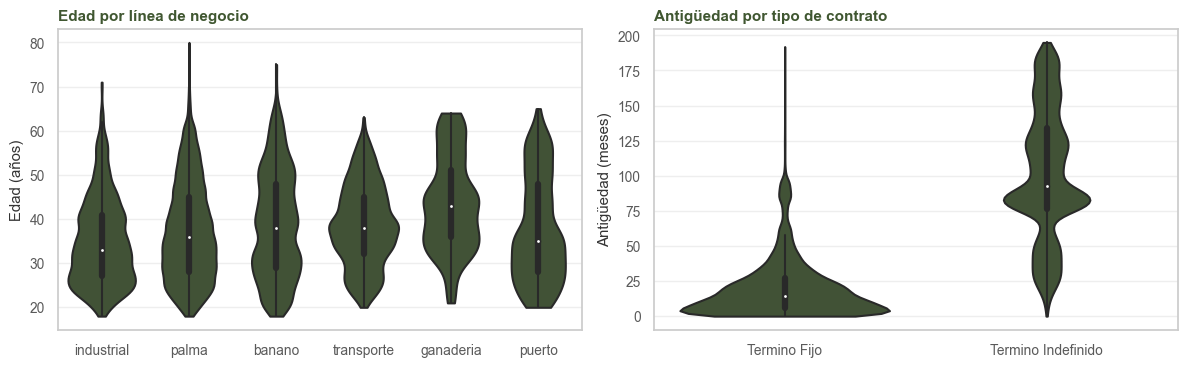

,numérica,grupo,H,p,ε²
0,edad,linea,688.3,1.6e-146,0.010
1,edad,contrato,18231.2,0.0e+00,0.270
2,edad,tipo_unidad,325.7,3.1e-69,0.005
3,antig_meses,linea,1217.0,6.1e-261,0.018
4,antig_meses,contrato,40844.0,0.0e+00,0.605
5,antig_meses,tipo_unidad,208.0,7.3e-44,0.003


In [7]:
filas = []
for v in NUM:
    for g in ['linea', 'contrato', 'tipo_unidad']:
        grupos = [x[v].dropna() for _, x in tr.groupby(g)]
        h, pv = stats.kruskal(*grupos)
        filas.append({'numérica': v, 'grupo': g, 'H': round(h, 1), 'p': f'{pv:.1e}',
                      'ε²': round(h / (len(tr) - 1), 3)})

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
sns.violinplot(data=tr, x='linea', y='edad', ax=ax[0], cut=0, color=VERDE)
ax[0].set(title='Edad por línea de negocio', xlabel='', ylabel='Edad (años)')
sns.violinplot(data=tr, x='contrato', y='antig_meses', ax=ax[1], cut=0, color=VERDE)
ax[1].set(title='Antigüedad por tipo de contrato', xlabel='', ylabel='Antigüedad (meses)')
plt.tight_layout()
plt.show()

pd.DataFrame(filas)

Quienes renuncian son más jóvenes (mediana de 29 frente a 36 años) y tienen mucha menos antigüedad
(12 frente a 38 meses), con efectos medianos (r = 0,35 y 0,42), los mayores del análisis. En
Kruskal-Wallis, el contrato explica el 60 % de la variabilidad de la antigüedad (ε² = 0,61) y el
27 % de la de la edad: el término fijo agrupa sobre todo a personas nuevas y jóvenes. Los efectos
del contrato y de la antigüedad, por tanto, se superponen en buena medida. Las diferencias entre
líneas y tipos de unidad son pequeñas (ε² ≤ 0,02), aunque muy significativas.

### Tasa por tramos y curva de riesgo

La relación con la renuncia se aprecia mejor como tasa por tramo que como diferencia de medianas.

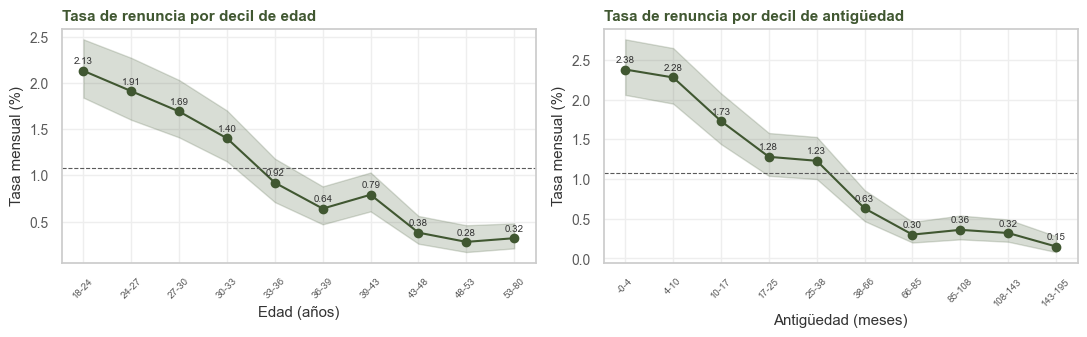

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for i, v in enumerate(NUM):
    t = tasa_ic(tr, pd.qcut(tr[v], 10, duplicates='drop'))
    x = range(len(t))
    ax[i].plot(x, t['tasa_%'], marker='o', color=VERDE)
    ax[i].fill_between(x, t.ic_bajo, t.ic_alto, alpha=0.2, color=VERDE)
    puntos(ax[i], x, t['tasa_%'])
    ax[i].set_xticks(list(x))
    ax[i].set_xticklabels([f'{iv.left:.0f}-{iv.right:.0f}' for iv in t.index], rotation=45,
                          fontsize=7)
    ax[i].axhline(BASE, ls='--', c=GRIS, lw=0.8)
    ax[i].set(title=f'Tasa de renuncia por decil de {NOMBRE[v]}', xlabel=UNIDAD[v],
              ylabel='Tasa mensual (%)')
plt.tight_layout()
plt.show()

La tasa por mes de antigüedad es la función de riesgo discreta (*hazard*): de quienes llegan al mes
*k* de antigüedad, la fracción que renuncia en ese mes, $\hat h_k = d_k / n_k$, con $d_k$ renuncias
entre las $n_k$ persona-mes que están en el mes *k*. Se calcula por separado para cada tipo de
contrato, porque son poblaciones distintas.

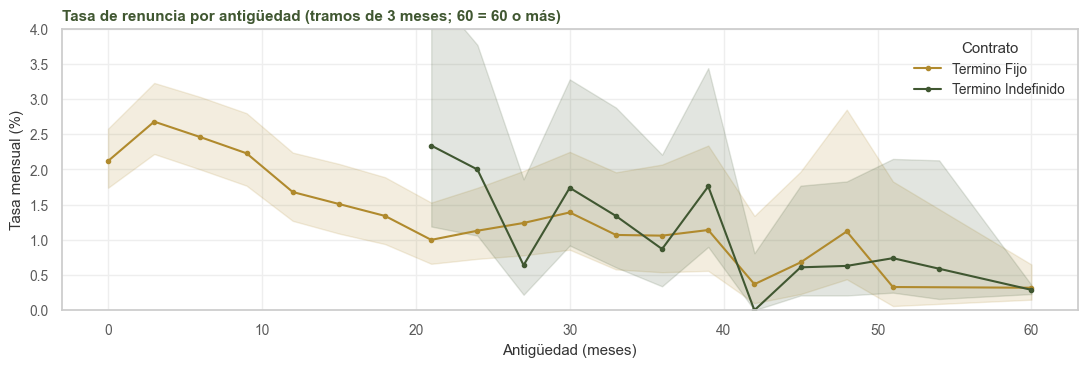

In [9]:
fig, ax = plt.subplots(figsize=(11, 3.8))
for contrato, color in [('Termino Fijo', ORO), ('Termino Indefinido', VERDE)]:
    s = tr[tr.contrato == contrato]
    tramo = (s.antig_meses // 3 * 3).clip(upper=60)
    t = tasa_ic(s, tramo, minimo=300)          # tramos con al menos 300 filas
    ax.plot(t.index, t['tasa_%'], marker='o', ms=3, label=contrato, color=color)
    ax.fill_between(t.index, t.ic_bajo, t.ic_alto, alpha=0.15, color=color)
ax.set(title='Tasa de renuncia por antigüedad (tramos de 3 meses; 60 = 60 o más)',
       xlabel='Antigüedad (meses)', ylabel='Tasa mensual (%)', ylim=(0, 4))
ax.legend(title='Contrato')
plt.tight_layout()
plt.show()

## Variables binarias

El primer mes de un episodio tiene una tasa mayor que el resto (1,66 % frente a 1,07 %).

In [10]:
pd.concat({v: tasa_ic(tr, v) for v in BIN})

filas  renuncias  tasa_%  ic_bajo  ic_alto
             primer_mes                                            
primer_mes   0           65905        703    1.07     0.99     1.15
             1            1625         27    1.66     1.14     2.41
reingreso    0           62110        658    1.06     0.98     1.14
             1            5420         72    1.33     1.06     1.67
traslado_12m 0           65716        709    1.08     1.00     1.16
             1            1814         21    1.16     0.76     1.76

## Variables categóricas

### Frecuencias y categorías poco frecuentes

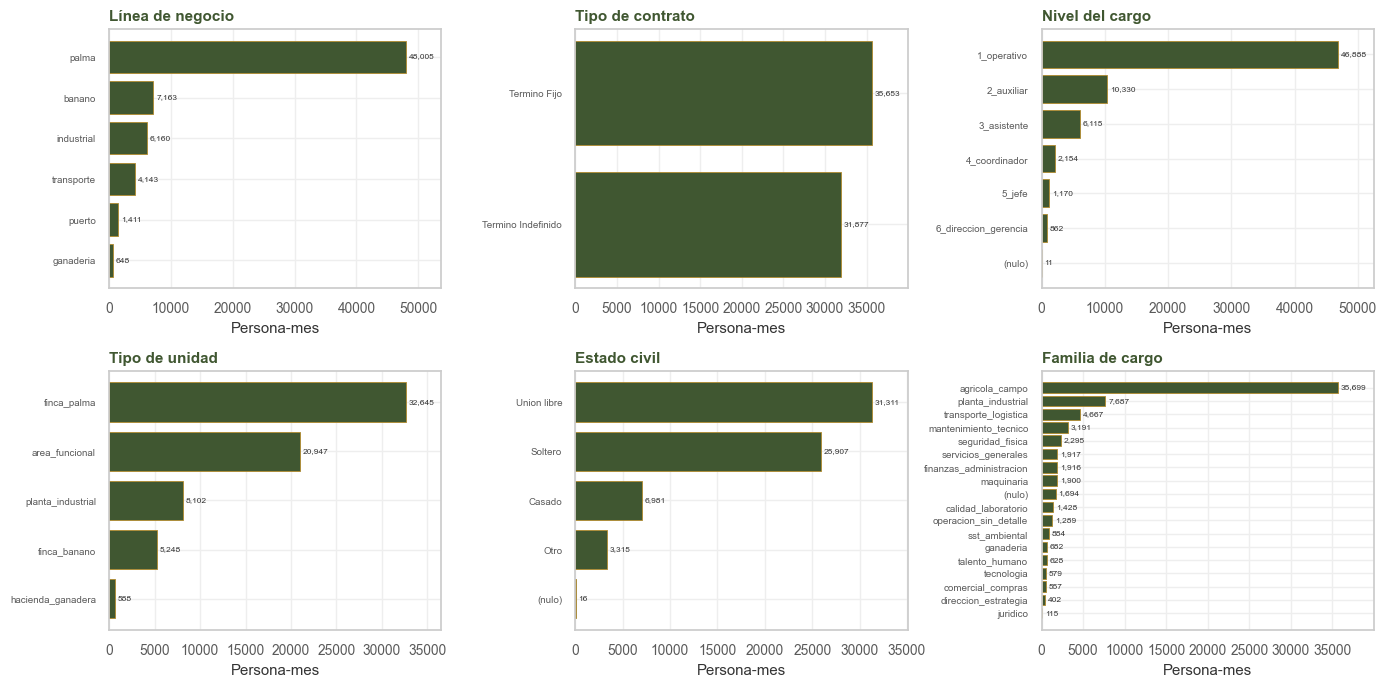

,categorías,con < 300 filas,filas en esas categorías
sociedad,22,3,553
linea,6,0,0
ubicacion,57,30,2506
genero,2,0,0
estado_civil,5,1,16
contrato,2,0,0
nivel,7,1,11
familia_cargo,18,1,115
oficio,42,1,115
tipo_unidad,5,0,0


In [11]:
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
for a, v in zip(ax.ravel(), ['linea', 'contrato', 'nivel', 'tipo_unidad', 'estado_civil',
                             'familia_cargo']):
    conteo = tr[v].fillna('(nulo)').value_counts()
    barras = a.barh(conteo.index[::-1], conteo.values[::-1], color=VERDE, **BORDE)
    etiquetar(a, barras, fontsize=6)
    a.set(title=NOMBRE[v].capitalize(), xlabel='Persona-mes')
    a.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

raras = {}
for v in CAT:
    conteo = tr[v].fillna('(nulo)').value_counts()
    raras[v] = {'categorías': tr[v].nunique(dropna=False),
                'con < 300 filas': int((conteo < 300).sum()),
                'filas en esas categorías': int(conteo[conteo < 300].sum())}
pd.DataFrame(raras).T

Las categorías con menos de 300 filas (unas tres renuncias esperadas) no permiten estimar su tasa.
En el `Pipeline` se agrupan en una categoría de infrecuentes (`OneHotEncoder(min_frequency=300)`),
que también recibe las categorías que aparezcan por primera vez en el test. Donde más pesa es en
`ubicacion`: 30 de sus 57 categorías, con 2.506 filas. En `oficio` casi no hace falta, porque los
oficios pequeños ya se agruparon en `otro_<familia>` al construir el panel.

### Asociación con el objetivo

Para cada variable se reportan la cardinalidad, el tamaño de la categoría más pequeña y la
asociación con el objetivo (chi-cuadrado y V de Cramér, $V = \sqrt{\chi^2 / (n \,(\min(r, c) - 1))}$,
que con un objetivo binario se reduce a $\sqrt{\chi^2 / n}$). Como se hacen 13 pruebas, los valores p se
corrigen por comparaciones múltiples con Holm (probabilidad de algún falso positivo) y con
Benjamini-Hochberg (proporción de falsos descubrimientos). Los gráficos muestran solo las
categorías con al menos 300 filas, porque por debajo el intervalo es demasiado ancho; la tabla sí
las cuenta.

In [12]:
filas = []
for v in CAT:
    x = tr[v].fillna('(nulo)')
    chi, pv, gl, _ = chi2_contingency(pd.crosstab(x, tr[OBJETIVO]).to_numpy(), correction=False)
    r = tasa(tr, x)
    filas.append({
        'variable': v,
        'categorías': x.nunique(),
        'filas cat. mín.': int(x.value_counts().min()),
        'cat. con < 5 renuncias': int((r.renuncias < 5).sum()),
        'chi2': round(chi, 1),
        'gl': gl,
        'p': f'{pv:.1e}',
        'V de Cramér': round(np.sqrt(chi / len(tr)), 3),
        'tasa mín %': round(r['tasa_%'].min(), 2),
        'tasa máx %': round(r['tasa_%'].max(), 2),
    })
asoc = pd.DataFrame(filas).set_index('variable').sort_values('V de Cramér', ascending=False)

# corrección por comparaciones múltiples
p_crudo = asoc.p.astype(float).to_numpy()
asoc['p Holm'] = [f'{x:.1e}' for x in multipletests(p_crudo, method='holm')[1]]
asoc['p FDR (BH)'] = [f'{x:.1e}' for x in multipletests(p_crudo, method='fdr_bh')[1]]
asoc['significativa (Holm, 5 %)'] = multipletests(p_crudo, method='holm')[0]
asoc

variable,categorías,filas cat. mín.,cat. con < 5 renuncias,chi2,gl,p,V de Cramér,tasa mín %,tasa máx %,p Holm,p FDR (BH),"significativa (Holm, 5 %)"
oficio,42,115,11,385.6,41,1.4e-57,0.076,0.00,3.27,1.8e-56,1.8e-56,True
ubicacion,57,1,33,331.1,56,1.1e-40,0.070,0.00,5.56,9.9e-40,2.9e-40,True
sociedad,22,130,8,279.5,21,4.7e-47,0.064,0.00,2.60,5.2e-46,2.0e-46,True
contrato,2,31877,0,228.1,1,1.6e-51,0.058,0.45,1.65,1.9e-50,1.0e-50,True
tipo_unidad,5,588,1,205.4,4,2.6e-43,0.055,0.68,2.99,2.6e-42,8.4e-43,True
linea,6,648,1,165.9,5,5.6e-34,0.050,0.62,2.55,4.5e-33,1.2e-33,True
familia_cargo,18,115,4,51.7,17,2.3e-05,0.028,0.00,2.38,1.4e-04,3.7e-05,True
estado_civil,5,16,1,33.9,4,7.9e-07,0.022,0.00,1.27,5.5e-06,1.5e-06,True
area_funcional,14,96,4,26.0,13,1.7e-02,0.020,0.00,1.88,6.8e-02,2.2e-02,False
proceso_planta,13,281,4,21.9,12,3.8e-02,0.018,0.46,2.10,1.1e-01,4.5e-02,False


```{admonition} Observación
:class: note
Con 67.530 filas casi todas las asociaciones resultan significativas y el valor p ordena
poco. El tamaño del efecto (V de Cramér) es el que permite comparar las variables.
```

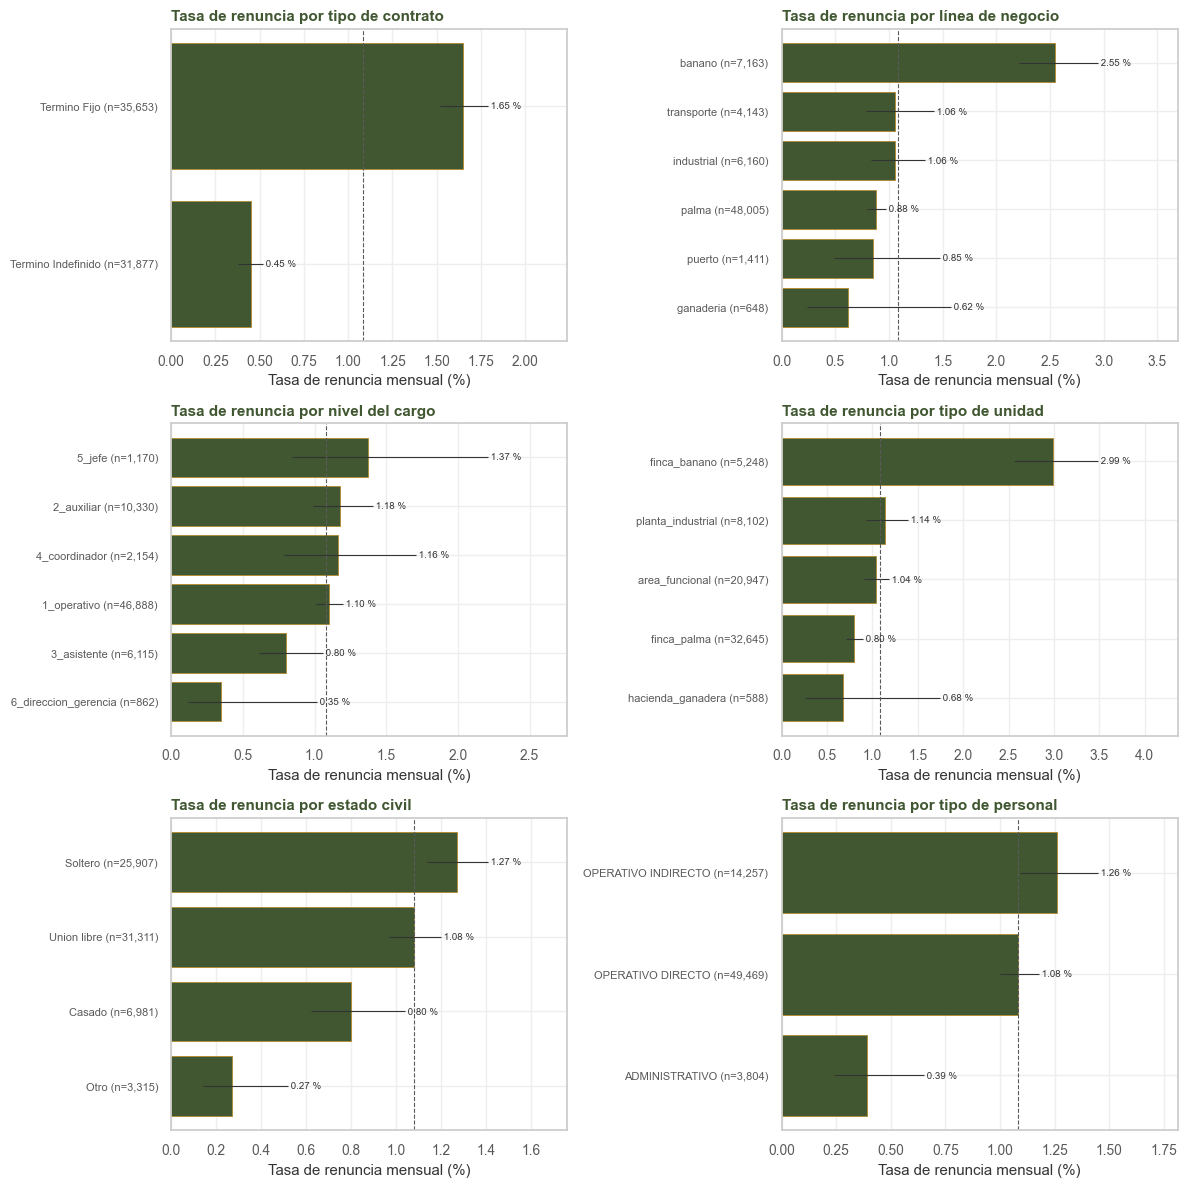

In [13]:
fig, ax = plt.subplots(3, 2, figsize=(12, 12))
for a, v in zip(ax.ravel(), ['contrato', 'linea', 'nivel', 'tipo_unidad', 'estado_civil',
                             'tipo_costos']):
    t = tasa_ic(tr, tr[v].fillna('(nulo)'), minimo=300)
    grafico_tasa(a, t, f'Tasa de renuncia por {NOMBRE[v]}', BASE)
plt.tight_layout()
plt.show()

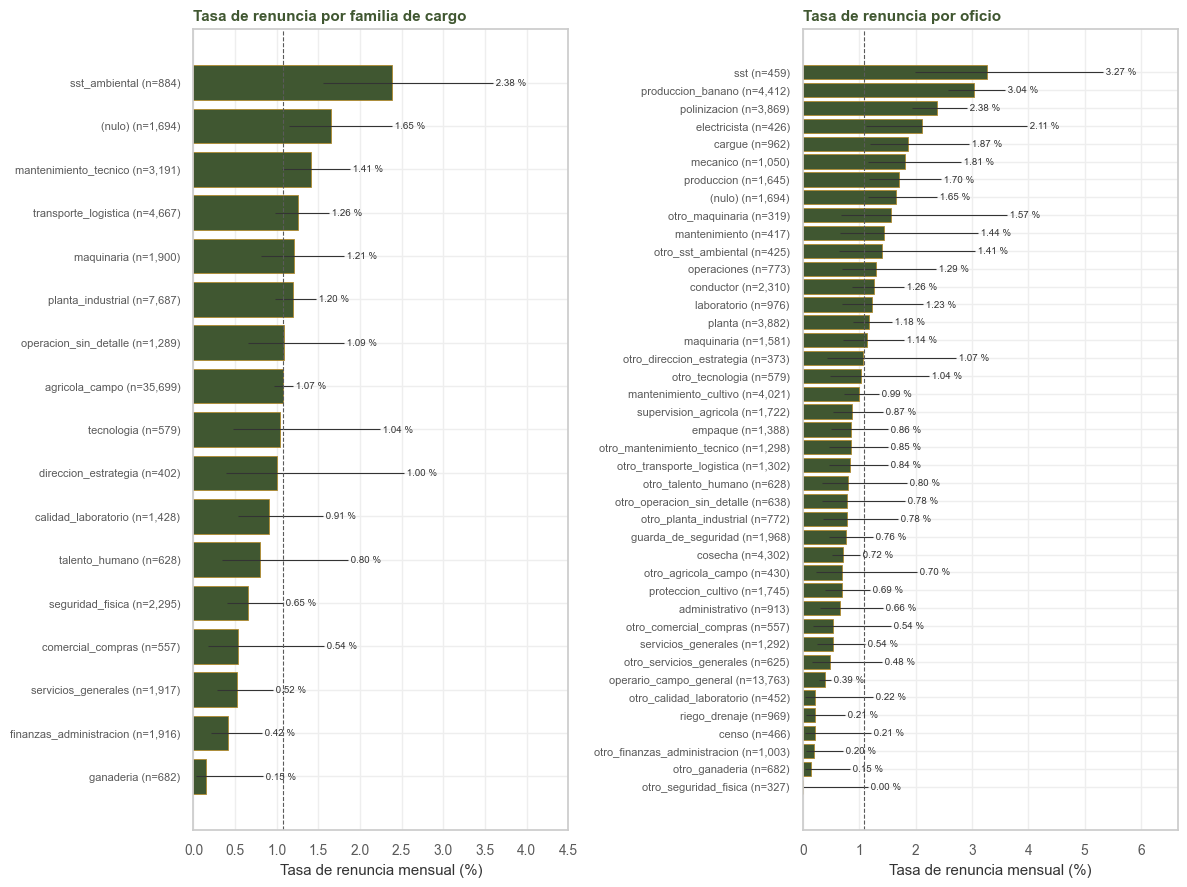

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 9))
for a, v in zip(ax, ['familia_cargo', 'oficio']):
    t = tasa_ic(tr, tr[v].fillna('(nulo)'), minimo=300)
    grafico_tasa(a, t, f'Tasa de renuncia por {NOMBRE[v]}', BASE)
plt.tight_layout()
plt.show()

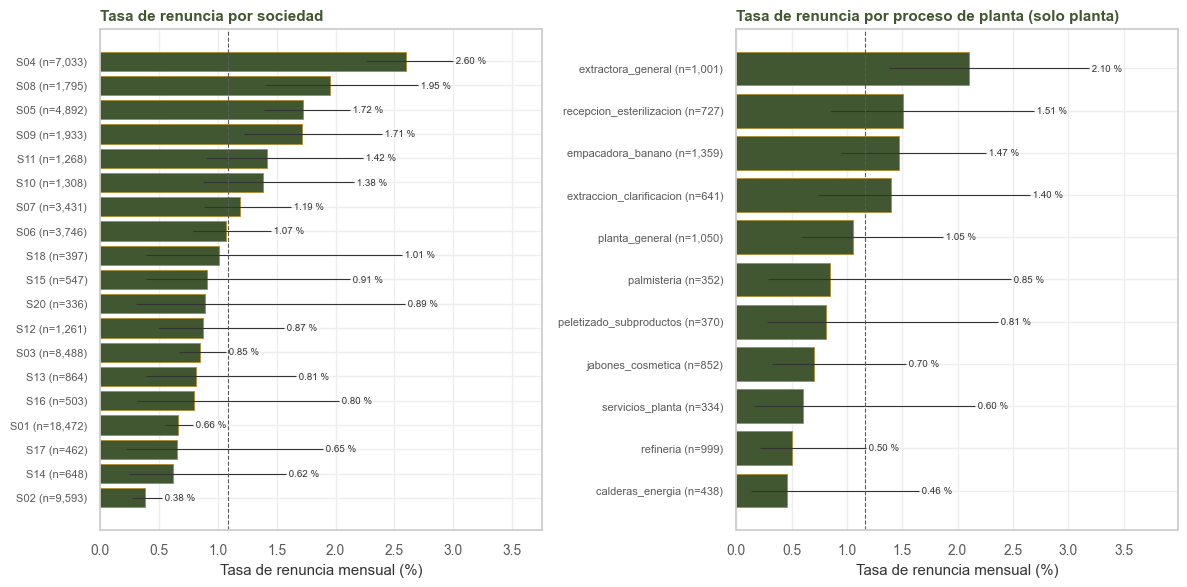

In [15]:
planta = tr[tr.proceso_planta != 'no_aplica']
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
grafico_tasa(ax[0], tasa_ic(tr, tr.sociedad, minimo=300), 'Tasa de renuncia por sociedad', BASE)
grafico_tasa(ax[1], tasa_ic(planta, planta.proceso_planta, minimo=300),
             'Tasa de renuncia por proceso de planta (solo planta)', 100 * planta[OBJETIVO].mean())
plt.tight_layout()
plt.show()

### Comparación entre niveles

Los gráficos muestran la tasa de cada categoría frente a la media. Para comparar las categorías entre
sí, cada una se contrasta con una referencia, la categoría más frecuente de su variable, mediante la
razón de tasas

$$
RR = \frac{a / n}{a_0 / n_0}, \qquad
\operatorname{IC}_{95\%} = RR \cdot \exp\!\left(\pm 1{,}96 \sqrt{\tfrac{1}{a} - \tfrac{1}{n}
  + \tfrac{1}{a_0} - \tfrac{1}{n_0}}\right),
$$

donde *a* y *n* son las renuncias y las filas de la categoría, y $a_0$ y $n_0$ las de la referencia.
Cada contraste se prueba con la prueba exacta de Fisher y los valores p se corrigen con Holm sobre
todos los contrastes del capítulo. Se incluyen las categorías con al menos 300 filas. La tabla
visible trae las variables de pocas categorías; la de las variables de muchas categorías está
plegada debajo.

In [16]:
def contraste(df, v, minimo=300):
    """Razón de tasas de cada categoría frente a la más frecuente, con IC y prueba de Fisher."""
    t = tasa(df, df[v].fillna('(nulo)'), minimo).sort_values('filas', ascending=False)
    ref = t.index[0]
    a0, n0 = t.loc[ref, 'renuncias'], t.loc[ref, 'filas']
    filas = []
    for nivel, r in t.iterrows():
        a, n = r.renuncias, r.filas
        fila = {'variable': NOMBRE[v], 'categoría': nivel, 'filas': int(n),
                'renuncias': int(a), 'tasa %': 100 * a / n}
        if nivel == ref:
            fila.update({'razón': 1.0, 'IC bajo': np.nan, 'IC alto': np.nan, 'p': np.nan})
        else:
            rr = (a / n) / (a0 / n0)
            ee = np.sqrt(1 / a - 1 / n + 1 / a0 - 1 / n0) if a > 0 else np.nan
            fila.update({'razón': rr, 'IC bajo': rr * np.exp(-1.96 * ee),
                         'IC alto': rr * np.exp(1.96 * ee),
                         'p': fisher_exact([[a, n - a], [a0, n0 - a0]])[1]})
        filas.append(fila)
    return pd.DataFrame(filas)


niveles = pd.concat([contraste(tr, v) for v in CAT], ignore_index=True)
con_p = niveles.p.notna()
niveles.loc[con_p, 'p Holm'] = multipletests(niveles.p[con_p], method='holm')[1]
niveles['referencia'] = np.where(con_p, '', 'ref.')
niveles = niveles.set_index(['variable', 'categoría'])
print(f'{con_p.sum()} contrastes; significativos con Holm al 5 %: '
      f'{(niveles["p Holm"] < 0.05).sum()}')

POCAS = ['contrato', 'linea', 'tipo_unidad', 'tipo_costos', 'nivel', 'estado_civil', 'genero']
columnas = ['filas', 'renuncias', 'tasa %', 'razón', 'IC bajo', 'IC alto', 'p Holm', 'referencia']
niveles.loc[[NOMBRE[v] for v in POCAS], columnas].round(3)

144 contrastes; significativos con Holm al 5 %: 28


filas  renuncias  tasa %  razón  \
variable         categoría                                               
tipo de contrato Termino Fijo          35653        588   1.649  1.000   
                 Termino Indefinido    31877        142   0.445  0.270   
línea de negocio palma                 48005        422   0.879  1.000   
                 banano                 7163        183   2.555  2.906   
                 industrial             6160         65   1.055  1.200   
                 transporte             4143         44   1.062  1.208   
                 puerto                 1411         12   0.850  0.967   
                 ganaderia               648          4   0.617  0.702   
tipo de unidad   finca_palma           32645        260   0.796  1.000   
                 area_funcional        20947        217   1.036  1.301   
                 planta_industrial      8102         92   1.136  1.426   
                 finca_banano           5248        157   2.992  3.756   
                 hacienda_ganadera       588          4   0.680  0.854   
tipo de personal OPERATIVO DIRECTO     49469        536   1.084  1.000   
                 OPERATIVO INDIRECTO   14257        179   1.256  1.159   
                 ADMINISTRATIVO         3804         15   0.394  0.364   
nivel del cargo  1_operativo           46888        515   1.098  1.000   
                 2_auxiliar            10330        122   1.181  1.075   
                 3_asistente            6115         49   0.801  0.730   
                 4_coordinador          2154         25   1.161  1.057   
                 5_jefe                 1170         16   1.368  1.245   
                 6_direccion_gerencia    862          3   0.348  0.317   
estado civil     Union libre           31311        337   1.076  1.000   
                 Soltero               25907        328   1.266  1.176   
                 Casado                 6981         56   0.802  0.745   
                 Otro                   3315          9   0.271  0.252   
género           Masculino             58632        648   1.105  1.000   
                 Femenino               8898         82   0.922  0.834   

                                       IC bajo  IC alto  p Holm referencia  
variable         categoría                                                  
tipo de contrato Termino Fijo              NaN      NaN     NaN       ref.  
                 Termino Indefinido      0.225    0.324   0.000             
línea de negocio palma                     NaN      NaN     NaN       ref.  
                 banano                  2.448    3.451   0.000             
                 industrial              0.926    1.556   1.000             
                 transporte              0.887    1.645   1.000             
                 puerto                  0.546    1.713   1.000             
                 ganaderia               0.263    1.874   1.000             
tipo de unidad   finca_palma               NaN      NaN     NaN       ref.  
                 area_funcional          1.087    1.556   0.496             
                 planta_industrial       1.125    1.806   0.500             
                 finca_banano            3.088    4.569   0.000             
                 hacienda_ganadera       0.319    2.285   1.000             
tipo de personal OPERATIVO DIRECTO         NaN      NaN     NaN       ref.  
                 OPERATIVO INDIRECTO     0.979    1.371   1.000             
                 ADMINISTRATIVO          0.218    0.607   0.001             
nivel del cargo  1_operativo               NaN      NaN     NaN       ref.  
                 2_auxiliar              0.884    1.308   1.000             
                 3_asistente             0.545    0.977   1.000             
                 4_coordinador           0.709    1.575   1.000             
                 5_jefe                  0.760    2.041   1.000             
                 6_direccion_gerencia    0.102 

In [17]:
with pd.option_context('display.max_rows', 200):
    display(niveles.drop(index=[NOMBRE[v] for v in POCAS])[columnas].round(3))

filas  renuncias  tasa %  \
variable          categoría                                                
sociedad          S01                           18472        122   0.660   
                  S02                            9593         36   0.375   
                  S03                            8488         72   0.848   
                  S04                            7033        183   2.602   
                  S05                            4892         84   1.717   
                  S06                            3746         40   1.068   
                  S07                            3431         41   1.195   
                  S09                            1933         33   1.707   
                  S08                            1795         35   1.950   
                  S10                            1308         18   1.376   
                  S11                            1268         18   1.420   
                  S12                            1261         11   0.872   
                  S13                             864          7   0.810   
                  S14                             648          4   0.617   
                  S15                             547          5   0.914   
                  S16                             503          4   0.795   
                  S17                             462          3   0.649   
                  S18                             397          4   1.008   
                  S20                             336          3   0.893   
ubicación         U038                           6696         99   1.478   
                  U008                           6202        108   1.741   
                  U036                           5838         29   0.497   
                  U033                           5715         17   0.297   
                  U046                           3736         44   1.178   
                  U041                           3476         17   0.489   
                  U032                           3457         46   1.331   
                  U011                           3154         74   2.346   
                  U051                           2987         22   0.737   
                  U002                           2769         13   0.469   
                  U057                           2703         31   1.147   
                  U043                           2387         22   0.922   
                  U039                           1942          8   0.412   
                  U001                           1883         19   1.009   
                  U012                           1878         62   3.301   
                  U040                           1454         15   1.032   
                  U034                           1431          5   0.349   
                  U016                           1292         18   1.393   
                  U042                           1068          5   0.468   
                  U009                           1001         24   2.398   
                  U031                            855          8   0.936   
                  U053                            668          5   0.749   
                  U056                            641          3   0.468   
                  U052                            583          3   0.515   
                  U044                            560          0   0.000   
                  U007                            338          9   2.663   
                  U037                            310          2   0.645   
familia de cargo  agricola_campo                35699        383   1.073   
                  planta_industrial              7687         92   1.197   
                  transporte_logistica           4667         59   1.264   
                  mantenimiento_tecnico          3191         45   1.410   
                  seguridad_fisica               2295         15   0.654   
                  se

De 144 contrastes, 28 son significativos con Holm, y se concentran en tres ejes:

- **Contrato.** El término indefinido renuncia a una tasa de 0,45 % mensual frente a 1,65 % del
  término fijo: una razón de 0,27 (IC de 0,23 a 0,32), o sea que el término fijo renuncia 3,7 veces
  más. Es la diferencia más precisa del capítulo.
- **Banano.** La línea de banano renuncia 2,9 veces más que la de palma (IC de 2,4 a 3,5), y la
  finca de banano 3,8 veces más que la de palma. En oficio, las razones más altas son las de banano
  (producción de banano 7,9 y polinización 6,2 veces el operario de campo general). Es una sola señal
  repartida entre variables anidadas. Industrial,
  transporte, puerto y ganadería no se distinguen de palma.
- **Personal administrativo.** Renuncia a una tercera parte de la tasa del operativo directo (0,36;
  IC de 0,22 a 0,61). En estado civil, la categoría "otro" (los estados poco frecuentes, agrupados)
  renuncia a la cuarta parte que la unión libre.

Otras diferencias que se ven en los gráficos no resisten la corrección: el nivel del cargo, el
género (0,83; IC de 0,66 a 1,05), soltero y casado frente a unión libre, y la mayoría de familias de
cargo y procesos de planta. En oficio la referencia es de riesgo bajo (0,39 %), por eso casi todas
las razones son mayores que uno. Como en el resto del capítulo, los contrastes tratan las filas como
independientes y son algo optimistas; el modelo del capítulo 7 los estima ajustando por las demás
variables.

## Información mutua frente al azar

La información mutua con el objetivo mide cuánto reduce una variable la incertidumbre sobre la
renuncia:

$$
I(X; Y) = \sum_{x} \sum_{y} p(x, y) \log \frac{p(x, y)}{p(x)\, p(y)} ,
$$

que vale cero si y solo si *X* y *Y* son independientes, y a diferencia de una correlación capta
relaciones no lineales. Crece con el número de categorías aunque no haya relación; por eso se
compara con su valor cuando el objetivo se permuta al azar (20 permutaciones) y se reporta el exceso
sobre ese valor.

In [18]:
def informacion_mutua(x, y):
    t = pd.crosstab(x, y).to_numpy().astype(float)
    t /= t.sum()
    px = t.sum(1, keepdims=True)
    py = t.sum(0, keepdims=True)
    nz = t > 0
    return float((t[nz] * np.log(t[nz] / (px @ py)[nz])).sum())


rng = np.random.default_rng(SEMILLA)
y = tr[OBJETIVO].to_numpy()
H = -(y.mean() * np.log(y.mean()) + (1 - y.mean()) * np.log(1 - y.mean()))   # entropía de y

filas = []
for v in PREDICTORAS:
    if v in NUM:
        x = pd.qcut(tr[v].fillna(-1), 20, duplicates='drop')
    else:
        x = tr[v].fillna('(nulo)')
    x = x.astype(str).to_numpy()
    observada = informacion_mutua(x, y)
    azar = np.mean([informacion_mutua(x, rng.permutation(y)) for _ in range(20)])
    filas.append({'variable': v, 'IM observada': observada, 'IM por azar': azar,
                  'exceso': observada - azar, '% de H(y)': 100 * (observada - azar) / H})
im = pd.DataFrame(filas).set_index('variable').sort_values('exceso', ascending=False)
im.round({'IM observada': 5, 'IM por azar': 5, 'exceso': 5, '% de H(y)': 2})

variable,IM observada,IM por azar,exceso,% de H(y)
antig_meses,0.00340,0.00014,0.00326,5.46
oficio,0.00258,0.00029,0.00229,3.84
edad,0.00231,0.00014,0.00217,3.63
ubicacion,0.00238,0.00041,0.00196,3.29
contrato,0.00183,0.00001,0.00182,3.05
sociedad,0.00187,0.00017,0.00170,2.85
tipo_unidad,0.00111,0.00002,0.00109,1.82
linea,0.00094,0.00004,0.00090,1.51
estado_civil,0.00032,0.00002,0.00030,0.50
familia_cargo,0.00042,0.00014,0.00027,0.46


## Interacciones

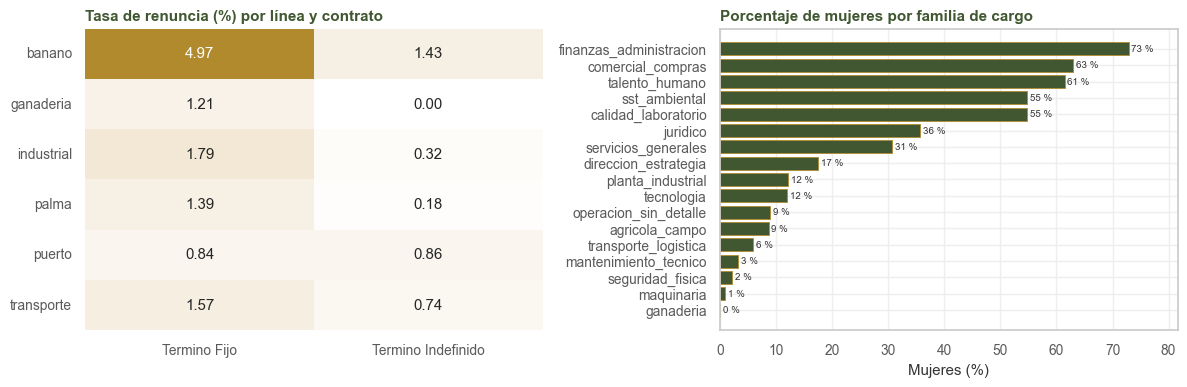

término fijo por línea (%):
linea
banano        32.0
ganaderia     51.0
industrial    50.0
palma         58.0
puerto        42.0
transporte    38.0


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
t = tr.pivot_table(index='linea', columns='contrato', values=OBJETIVO, aggfunc='mean') * 100
sns.heatmap(t, annot=True, fmt='.2f', cmap='oro', ax=ax[0], cbar=False)
ax[0].set(title='Tasa de renuncia (%) por línea y contrato', xlabel='', ylabel='')

mujeres = tr.groupby('familia_cargo').genero.apply(lambda s: 100 * (s == 'Femenino').mean())
mujeres = mujeres.sort_values()
barras = ax[1].barh(mujeres.index, mujeres.values, color=VERDE, **BORDE)
etiquetar(ax[1], barras, '{:.0f} %')
ax[1].set(title='Porcentaje de mujeres por familia de cargo', xlabel='Mujeres (%)', ylabel='')
plt.tight_layout()
plt.show()

fijo_linea = tr.groupby('linea').contrato.apply(lambda s: 100 * (s == 'Termino Fijo').mean())
print('término fijo por línea (%):')
print(fijo_linea.round(0).to_string())

## Síntesis

1. La antigüedad es la variable con más información (5,5 % de la entropía del objetivo, el doble
   que cualquier categórica una vez descontado el azar). La relación no es lineal: en término fijo
   la tasa es de 2,4 % el primer año, 1,4 % el segundo, 1,1 % hasta el cuarto y 0,4 % después, por
   lo que conviene incluirla en logaritmo o por tramos.
2. El término fijo multiplica la tasa por 3,7 (1,65 % frente a 0,45 %), pero buena parte de ese
   efecto corresponde a la antigüedad (sección 3.2).
3. El grupo de mayor riesgo es banano con término fijo, con una tasa de 5,0 % mensual, cuatro veces
   la media. En puerto el contrato no marca diferencia (0,84 % frente a 0,86 %). El efecto del
   contrato depende de la línea, y un modelo aditivo no captura esa interacción sin un término
   explícito.
4. La tasa baja de forma monótona con la edad, que está correlacionada con la antigüedad
   (capítulo 4).
5. `oficio`, `ubicacion` y `sociedad` tienen señal, pero muchas categorías con menos de cinco
   renuncias (33 de 57 ubicaciones). Para no ajustar ruido, las categorías raras se agrupan.
6. Tras la corrección de Holm dejan de ser significativas `genero`, `nivel`, `area_funcional` y
   `proceso_planta` (esta última solo discrimina dentro de planta), y `traslado_12m` no difiere. Se
   conservan en el modelo base para que la regularización determine su aporte, aunque se espera que
   sea marginal.
7. El primer mes de un episodio tiene más riesgo, y es donde `familia_cargo` y `oficio` son nulos;
   por eso el nulo se trata como una categoría (sección 1.4).